In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
import matplotlib.transforms as mtransforms
import pandas as pd
import numpy as np

PRICE_SOURCE_TZ = "America/New_York"
ANALYSIS_TZ = "Europe/Amsterdam"


# price data exploration

In [3]:
DATA_DIR = Path("Data/EURUSD 1m")
YEARS_TO_LOAD = range(2000, 2026)

all_price_files = sorted(DATA_DIR.glob("DAT_ASCII_EURUSD_M1_*.csv"))
selected_years = {str(year) for year in YEARS_TO_LOAD}
price_files = [path for path in all_price_files if path.stem.split("_")[-1] in selected_years]

column_names = ["timestamp_raw", "open", "high", "low", "close"]
dtype_map = {
    "open": "float32",
    "high": "float32",
    "low": "float32",
    "close": "float32",
}

frames = []
for price_file in price_files:
    year_df = pd.read_csv(
        price_file,
        sep=";",
        header=None,
        usecols=range(len(column_names)),
        names=column_names,
        dtype=dtype_map,
    )
    year_df["timestamp"] = (
        pd.to_datetime(year_df["timestamp_raw"], format="%Y%m%d %H%M%S", errors="raise")
        .dt.tz_localize(PRICE_SOURCE_TZ)
        .dt.tz_convert(ANALYSIS_TZ)
    )
    frames.append(year_df.drop(columns="timestamp_raw"))

eurusd = (
    pd.concat(frames, ignore_index=True)
    .sort_values("timestamp", kind="stable")
    .reset_index(drop=True)
)

loaded_years = [path.stem.split("_")[-1] for path in price_files]

print(f"Loaded {len(eurusd):,} rows from {len(price_files)} files.")
print(f"Years loaded: {loaded_years[0]} -> {loaded_years[-1]}")
print(f"Date range: {eurusd['timestamp'].min()} -> {eurusd['timestamp'].max()}")
display(eurusd.head())


Loaded 8,720,941 rows from 26 files.
Years loaded: 2000 -> 2025
Date range: 2000-05-30 23:27:00+02:00 -> 2025-12-31 22:57:00+01:00


,open,high,low,close,timestamp
0,0.9302,0.9302,0.9302,0.9302,2000-05-30 23:27:00+02:00
1,0.9304,0.9305,0.9304,0.9305,2000-05-30 23:35:00+02:00
2,0.9304,0.9304,0.9303,0.9303,2000-05-30 23:38:00+02:00
3,0.9301,0.9301,0.9300,0.9300,2000-05-30 23:43:00+02:00
4,0.9298,0.9298,0.9297,0.9297,2000-05-30 23:44:00+02:00


Overview


,value
rows,8720941.0
duplicate_timestamps,360.0
missing_values_total,0.0
non_monotonic_steps,0.0
gaps_larger_than_1_minute,335583.0
largest_gap_minutes,15547.0
days_with_1440_rows,531.0
days_below_1440_rows,7243.0


Missing values by column


,missing_values
open,0
high,0
low,0
close,0
timestamp,0


Rows per year


timestamp,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
rows,143167,230767,213000,316351,328426,315635,307176,299782,347355,355880,...,372679,371635,372607,372530,372335,369502,372865,322638,372379,372084


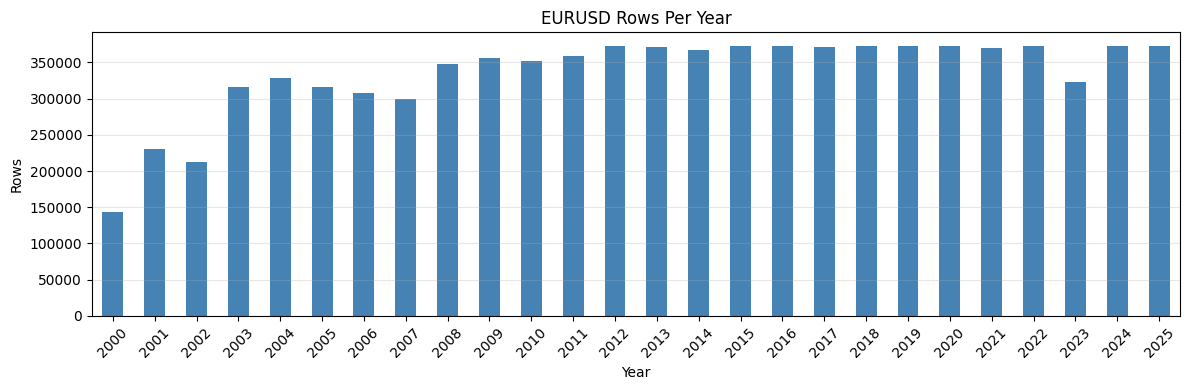

In [4]:
timestamp_delta_minutes = eurusd["timestamp"].diff().dt.total_seconds().div(60)

missing_values = eurusd.isna().sum().rename("missing_values").to_frame()
yearly_counts = (
    eurusd.groupby(eurusd["timestamp"].dt.year)
    .size()
    .rename("rows")
    .to_frame()
)
daily_counts = (
    eurusd.groupby(eurusd["timestamp"].dt.normalize())
    .size()
    .rename("rows")
)


overview = pd.Series(
    {
        "rows": len(eurusd),
        "duplicate_timestamps": int(eurusd["timestamp"].duplicated().sum()),
        "missing_values_total": int(missing_values["missing_values"].sum()),
        "non_monotonic_steps": int((timestamp_delta_minutes < 0).sum()),
        "gaps_larger_than_1_minute": int((timestamp_delta_minutes > 1).sum()),
        "largest_gap_minutes": float(timestamp_delta_minutes.max()),
        "days_with_1440_rows": int((daily_counts == 1440).sum()),
        "days_below_1440_rows": int((daily_counts < 1440).sum()),
    },
    name="value",
).to_frame()

print("Overview")
display(overview)

print("Missing values by column")
display(missing_values)

print("Rows per year")
display(yearly_counts.T)

fig, ax = plt.subplots(figsize=(12, 4))
yearly_counts["rows"].plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("EURUSD Rows Per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Rows")
ax.ticklabel_format(style="plain", axis="y")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



# 2023 specific missingness

In [5]:
ts_2023 = eurusd.loc[eurusd["timestamp"].dt.year == 2023, "timestamp"]
delta_2023 = ts_2023.diff().dt.total_seconds().div(60)

findings_2023 = pd.DataFrame(
    [
        {
            "rows_2022": int(yearly_counts.loc[2022, "rows"]),
            "rows_2023": int(yearly_counts.loc[2023, "rows"]),
            "rows_2024": int(yearly_counts.loc[2024, "rows"]),
            "1h_gaps": int((delta_2023 == 61).sum()),
            "2h_gaps": int((delta_2023 == 121).sum()),
        }
    ]
)

display(findings_2023)


,rows_2022,rows_2023,rows_2024,1h_gaps,2h_gaps
0,372865,322638,372379,587,85


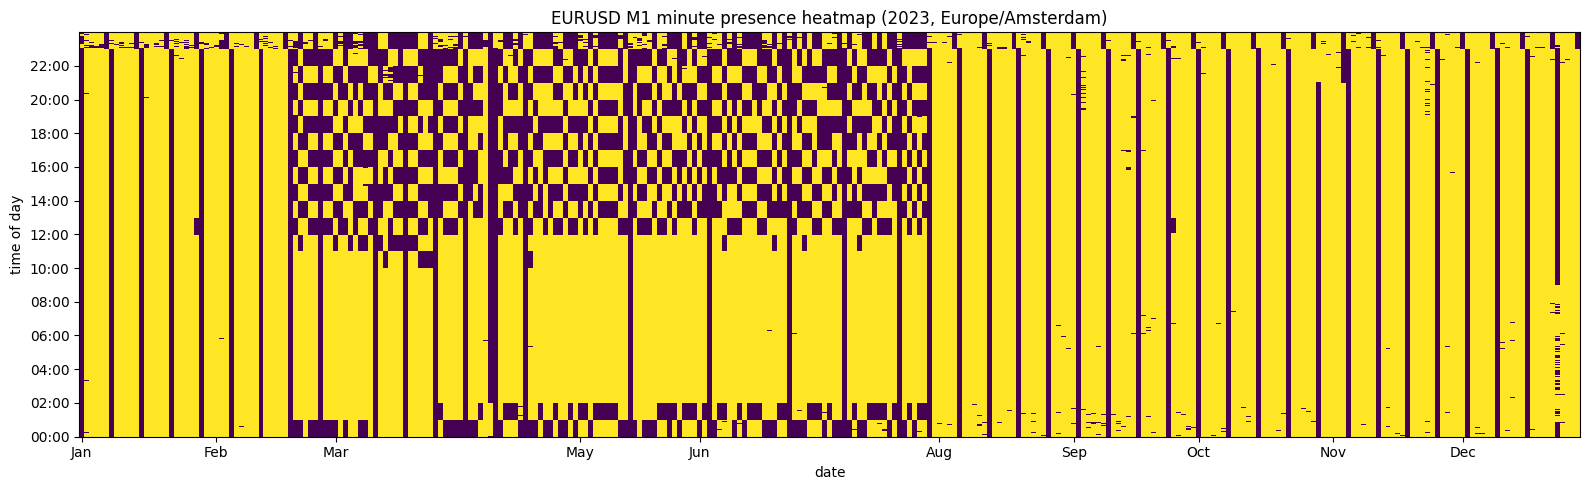

In [6]:
eurusd_2023 = eurusd.loc[eurusd["timestamp"].dt.year == 2023, ["timestamp"]].copy()

eurusd_2023["day"] = eurusd_2023["timestamp"].dt.normalize()
eurusd_2023["minute_of_day"] = (
    eurusd_2023["timestamp"].dt.hour * 60
    + eurusd_2023["timestamp"].dt.minute
)
eurusd_2023["present"] = 1

heatmap_2023 = (
    eurusd_2023.pivot_table(
        index="minute_of_day",
        columns="day",
        values="present",
        aggfunc="max",
        fill_value=0,
    )
    .sort_index(axis=1)
)

fig, ax = plt.subplots(figsize=(16, 5))
ax.imshow(
    heatmap_2023.values,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
)

ax.set_title(f"EURUSD M1 minute presence heatmap (2023, {ANALYSIS_TZ})")
ax.set_xlabel("date")
ax.set_ylabel("time of day")

yticks = range(0, 1440, 120)
ax.set_yticks(list(yticks))
ax.set_yticklabels([f"{h:02d}:00" for h in range(0, 24, 2)])

day_index = pd.to_datetime(heatmap_2023.columns)
month_positions = [i for i, d in enumerate(day_index) if d.day == 1]
month_labels = [d.strftime("%b") for d in day_index[month_positions]]
ax.set_xticks(month_positions)
ax.set_xticklabels(month_labels)

plt.tight_layout()
plt.show()

# Event data exploration

In [7]:
EVENT_FILES = {
    "EUR": Path("Data/eur_events_backup.xlsx"),
    "US": Path("Data/us_events_backup.xlsx"),
}

event_frames = []
for region, workbook_path in EVENT_FILES.items():
    workbook = pd.read_excel(
        workbook_path,
        sheet_name=None,
        usecols="A:D",
        engine="openpyxl",
        na_values=["#N/A N/A"],
    )
    for event_name, event_df in workbook.items():
        event_df = event_df.copy()
        event_df.columns = ["date", "survey", "actual", "datetime_raw"]
        event_df["region"] = region
        event_df["event_name"] = event_name
        event_frames.append(event_df)

events = pd.concat(event_frames, ignore_index=True)
events["date"] = pd.to_datetime(events["date"], errors="coerce")
events["datetime_raw"] = pd.to_datetime(events["datetime_raw"], errors="coerce")

events["survey"] = pd.to_numeric(events["survey"], errors="coerce")
events["actual"] = pd.to_numeric(events["actual"], errors="coerce")

event_row_mask = events[["date", "survey", "actual", "datetime_raw"]].notna().any(axis=1)
helper_only_rows_dropped = int((~event_row_mask).sum())
events = events.loc[event_row_mask].copy()

events["datetime"] = (
    events["datetime_raw"]
    .dt.tz_localize(ANALYSIS_TZ, ambiguous="NaT", nonexistent="shift_forward")
)

events = (
    events.sort_values(["datetime", "region", "event_name"], kind="stable")
    .reset_index(drop=True)
)

print(f"Loaded {len(events):,} event rows from {len(EVENT_FILES)} workbooks.")
print(f"Date range: {events['datetime'].min()} -> {events['datetime'].max()}")
display(events.head())


Loaded 2,747 event rows from 2 workbooks.
Date range: 2000-01-03 16:00:00+01:00 -> 2026-03-19 13:15:00+01:00


,date,survey,actual,datetime_raw,region,event_name,datetime
0,2000-01-03,56.0,55.5,2000-01-03 16:00:00,US,bus_cond,2000-01-03 16:00:00+01:00
1,2000-01-04,NaN,9.8,2000-01-04 11:00:00,EUR,unempl_rate,2000-01-04 11:00:00+01:00
2,2000-01-07,245.0,315.0,2000-01-07 14:30:00,US,NFP,2000-01-07 14:30:00+01:00
3,2000-01-07,4.1,4.1,2000-01-07 14:30:00,US,unempl_rate,2000-01-07 14:30:00+01:00
4,2000-02-01,NaN,9.6,2000-02-01 11:00:00,EUR,unempl_rate,2000-02-01 11:00:00+01:00


Events overview


,value
rows,2747
helper_only_rows_dropped,750
regions,2
event_types,6
unique_datetimes,2243
missing_values_total,68
missing_survey,64
missing_actual,2
date_range_start,2000-01-03 16:00:00+01:00
date_range_end,2026-03-19 13:15:00+01:00


Missing values by column


,date,survey,actual,datetime_raw,region,event_name,datetime
missing_values,0,64,2,1,0,0,1


Rows by region and event


event_name,NFP,bus_cond,cb_target_rate,cpi_yoy,gdp,unempl_rate
region,,,,,,
EUR,0,224,276,288,100,315
US,314,315,216,281,104,314


Rows per year and region


year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
region,,,,,,,,,,,,,,,,,,,,,
EUR,19,46,49,51,51,51,51,52,53,52,...,48,48,48,37,36,36,36,36,36,9
US,48,51,51,60,60,60,60,60,62,60,...,60,60,60,61,60,60,60,60,56,15


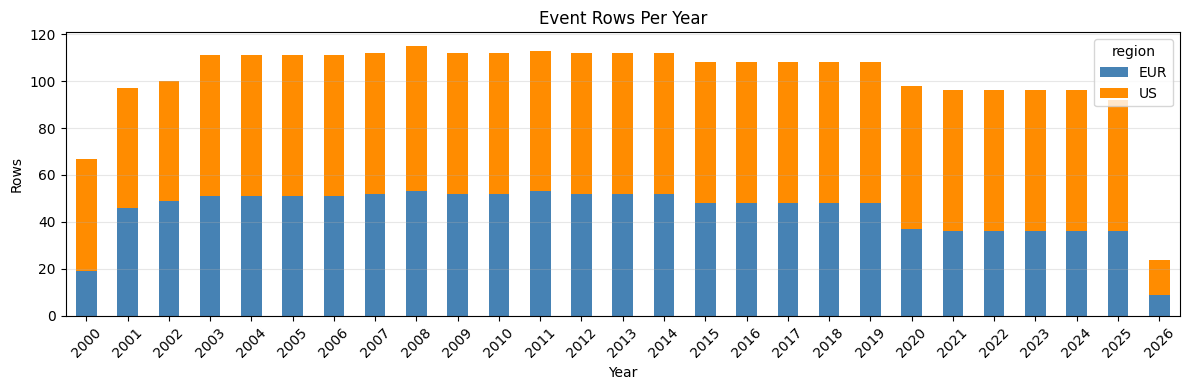

In [8]:
events_missing_values = events.isna().sum().rename("missing_values").to_frame()
events_rows_by_region_event = (
    events.groupby(["region", "event_name"])
    .size()
    .rename("rows")
    .unstack(fill_value=0)
)
events_rows_per_year = (
    events.groupby([events["datetime"].dt.year.rename("year"), "region"])
    .size()
    .rename("rows")
    .unstack(fill_value=0)
)
events_rows_per_year.index = events_rows_per_year.index.astype(int)

events_overview = pd.Series(
    {
        "rows": len(events),
        "helper_only_rows_dropped": helper_only_rows_dropped,
        "regions": events["region"].nunique(),
        "event_types": events["event_name"].nunique(),
        "unique_datetimes": events["datetime"].nunique(),
        "missing_values_total": int(events_missing_values["missing_values"].sum()),
        "missing_survey": int(events["survey"].isna().sum()),
        "missing_actual": int(events["actual"].isna().sum()),
        "date_range_start": events["datetime"].min(),
        "date_range_end": events["datetime"].max(),
    },
    name="value",
).to_frame()

print("Events overview")
display(events_overview)

print("Missing values by column")
display(events_missing_values.T)

print("Rows by region and event")
display(events_rows_by_region_event)

print("Rows per year and region")
display(events_rows_per_year.T)

fig, ax = plt.subplots(figsize=(12, 4))
events_rows_per_year.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Event Rows Per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Rows")
ax.ticklabel_format(style="plain", axis="y")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [9]:
events_study_flags = events.assign(
    missing_date=events["date"].isna(),
    missing_datetime=events["datetime"].isna(),
    missing_survey=events["survey"].isna(),
    missing_actual=events["actual"].isna(),
)
events_study_flags["usable_for_timing"] = events_study_flags["datetime"].notna()
events_study_flags["usable_for_surprise"] = events_study_flags[["datetime", "survey", "actual"]].notna().all(axis=1)


events_missing_by_region_event = (
    events_study_flags.groupby(["region", "event_name"])
    .agg(
        rows=("event_name", "size"),
        missing_datetime=("missing_datetime", "sum"),
        missing_survey=("missing_survey", "sum"),
        missing_actual=("missing_actual", "sum"),
        usable_for_surprise=("usable_for_surprise", "sum"),
    )
    .assign(
        pct_missing_datetime=lambda df: (100 * df["missing_datetime"] / df["rows"]).round(1),
        pct_missing_survey=lambda df: (100 * df["missing_survey"] / df["rows"]).round(1),
        pct_missing_actual=lambda df: (100 * df["missing_actual"] / df["rows"]).round(1),
    )
)
events_missing_by_region_event = events_missing_by_region_event.groupby(level="region", group_keys=False).apply(
    lambda df: df.sort_values(["missing_datetime", "missing_survey", "missing_actual", "rows"], ascending=False)
)



print("Missingness by region and event")
display(events_missing_by_region_event)



Missingness by region and event


rows  missing_datetime  missing_survey  missing_actual  \
region event_name                                                               
EUR    unempl_rate      315                 1               5               0   
       gdp              100                 0              19               0   
       bus_cond         224                 0              18               0   
       cb_target_rate   276                 0               4               2   
       cpi_yoy          288                 0               0               0   
US     cpi_yoy          281                 0              12               0   
       cb_target_rate   216                 0               6               0   
       bus_cond         315                 0               0               0   
       NFP              314                 0               0               0   
       unempl_rate      314                 0               0               0   
       gdp              104                 0               0               0   

                       usable_for_surprise  pct_missing_datetime  \
region event_name                                                  
EUR    unempl_rate                     310                   0.3   
       gdp                              81                   0.0   
       bus_cond                        206                   0.0   
       cb_target_rate                  270                   0.0   
       cpi_yoy                         288                   0.0   
US     cpi_yoy                         269                   0.0   
       cb_target_rate                  210                   0.0   
       bus_cond                        315                   0.0   
       NFP                             314                   0.0   
       unempl_rate                     314                   0.0   
       gdp                             104                   0.0   

                       pct_missing_survey  pct_missing_actual  
region event_name                                              
EUR    unempl_rate                    1.6                 0.0  
       gdp                           19.0                 0.0  
       bus_cond                       8.0                 0.0  
       cb_target_rate                 1.4                 0.7  
       cpi_yoy                        0.0                 0.0  
US     cpi_yoy                        4.3                 0.0  
       cb_target_rate                 2.8                 0.0  
       bus_cond                       0.0                 0.0  
       NFP                            0.0                 0.0  
       unempl_rate                    0.0                 0.0  
       gdp                            0.0                 0.0

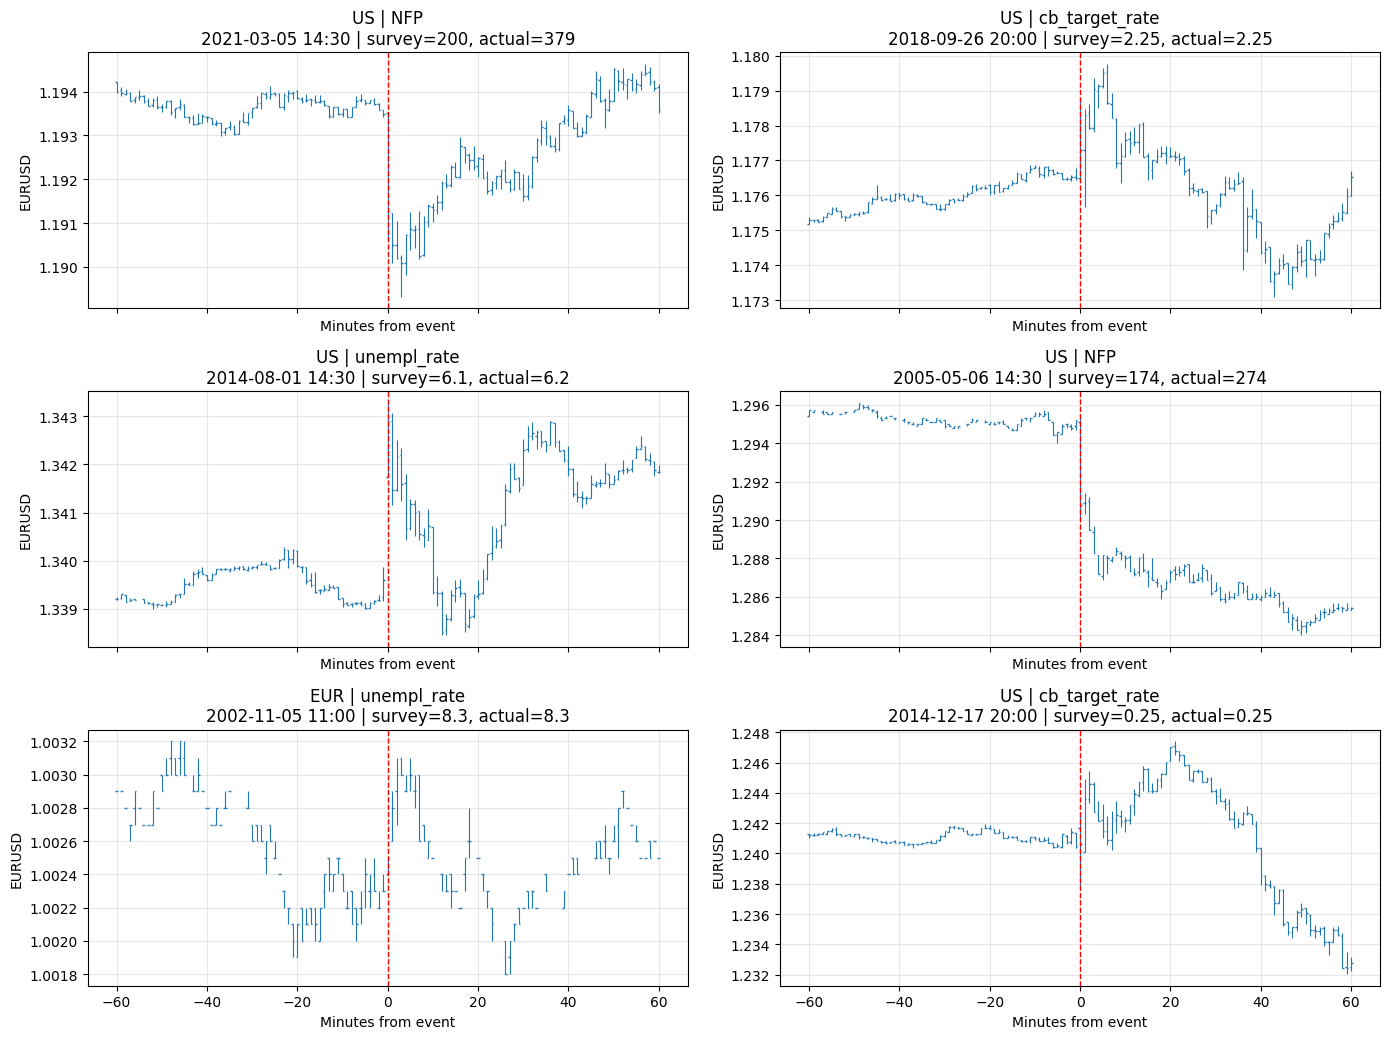

In [10]:
event_types_to_check = ["cpi_yoy", "unempl_rate", "gdp", "cb_target_rate", "NFP"]
window_minutes = 60
n_examples = 6
random_state = 1

candidate_events = (
    events.loc[
        events["event_name"].isin(event_types_to_check) & events["datetime"].notna(),
        ["region", "event_name", "datetime", "survey", "actual"],
    ]
    .drop_duplicates(subset=["region", "event_name", "datetime"])
    .sample(frac=1, random_state=random_state)
    .reset_index(drop=True)
)

price_timestamps = eurusd["timestamp"].to_numpy()
selected_event_windows = []

for event in candidate_events.itertuples(index=False):
    event_time = event.datetime
    window_start = event_time - pd.Timedelta(minutes=window_minutes)
    window_end = event_time + pd.Timedelta(minutes=window_minutes)

    left = price_timestamps.searchsorted(window_start, side="left")
    right = price_timestamps.searchsorted(window_end, side="right")
    window = eurusd.iloc[left:right][["timestamp", "open", "high", "low", "close"]].copy()

    if window.empty:
        continue

    window["minutes_from_event"] = (
        window["timestamp"]
        .sub(event_time)
        .dt.total_seconds()
        .div(60)
    )

    if window["minutes_from_event"].min() > -window_minutes or window["minutes_from_event"].max() < window_minutes:
        continue

    max_gap_minutes = window["timestamp"].diff().dt.total_seconds().div(60).dropna().max()
    if pd.notna(max_gap_minutes) and max_gap_minutes > 5:
        continue

    selected_event_windows.append((event, window))
    if len(selected_event_windows) == n_examples:
        break

n_cols = 2
n_rows = max(1, (len(selected_event_windows) + n_cols - 1) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows), sharex=True)
axes = pd.Series(axes.ravel() if hasattr(axes, "ravel") else [axes])

for ax, (event, window) in zip(axes, selected_event_windows):
    survey_text = "NA" if pd.isna(event.survey) else f"{event.survey:g}"
    actual_text = "NA" if pd.isna(event.actual) else f"{event.actual:g}"

    x = window["minutes_from_event"]

    ax.vlines(x, window["low"], window["high"], linewidth=0.8)
    ax.hlines(window["open"], x - 0.35, x, linewidth=1.0)
    ax.hlines(window["close"], x, x + 0.35, linewidth=1.0)

    ax.axvline(0,color="red", linestyle="--", linewidth=1)
    ax.set_title(
        f"{event.region} | {event.event_name}\n"
        f"{event.datetime.strftime('%Y-%m-%d %H:%M')} | survey={survey_text}, actual={actual_text}"
    )
    ax.set_xlabel("Minutes from event")
    ax.set_ylabel("EURUSD")
    ax.grid(alpha=0.3)

for ax in axes[len(selected_event_windows):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


# Surprise distribution per event type

In [11]:
surprise_df = events.dropna(subset=["survey", "actual"]).copy()
surprise_df["surprise"] = surprise_df["actual"] - surprise_df["survey"]

surprise_stats = (
    surprise_df.groupby(["region", "event_name"])["surprise"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .rename(columns={"count": "n"})
    .sort_values(["region", "n"], ascending=[True, False])
)
surprise_stats["skew"] = surprise_df.groupby(["region", "event_name"])["surprise"].skew()
surprise_stats["kurtosis"] = surprise_df.groupby(["region", "event_name"])["surprise"].apply(
    lambda x: x.kurtosis()
)

display(surprise_stats.round(4))

n     mean       std     min  median       max  \
region event_name                                                         
EUR    unempl_rate     310  -0.0197    0.1063   -0.90    0.00      0.40   
       cpi_yoy         288   0.0111    0.1501   -0.40    0.00      0.80   
       cb_target_rate  270   0.0015    0.0651   -0.50    0.00      0.25   
       bus_cond        206   0.0019    0.1757   -0.56   -0.01      0.50   
       gdp              81   0.0407    0.1421   -0.20    0.00      0.70   
US     bus_cond        315   0.1143    1.8304   -6.00    0.00      7.40   
       NFP             314  31.5191  588.1838 -734.00   -1.50  10009.00   
       unempl_rate     314  -0.0573    0.3779   -5.70    0.00      0.60   
       cpi_yoy         269   0.0089    0.1491   -0.40    0.00      0.60   
       cb_target_rate  210  -0.0042    0.0494   -0.25    0.00      0.25   
       gdp             104   0.0173    0.2671   -1.10    0.00      0.70   

                          skew  kurtosis  
region event_name                         
EUR    unempl_rate     -1.7656   15.7072  
       cpi_yoy          0.8305    4.5300  
       cb_target_rate  -0.9315   21.9022  
       bus_cond         0.0335    0.4773  
       gdp              1.8403    5.7661  
US     bus_cond         0.2561    1.0157  
       NFP             15.7806  266.9147  
       unempl_rate    -11.0727  160.3438  
       cpi_yoy          0.5333    1.5650  
       cb_target_rate  -2.1730   22.1018  
       gdp             -0.6660    2.6151

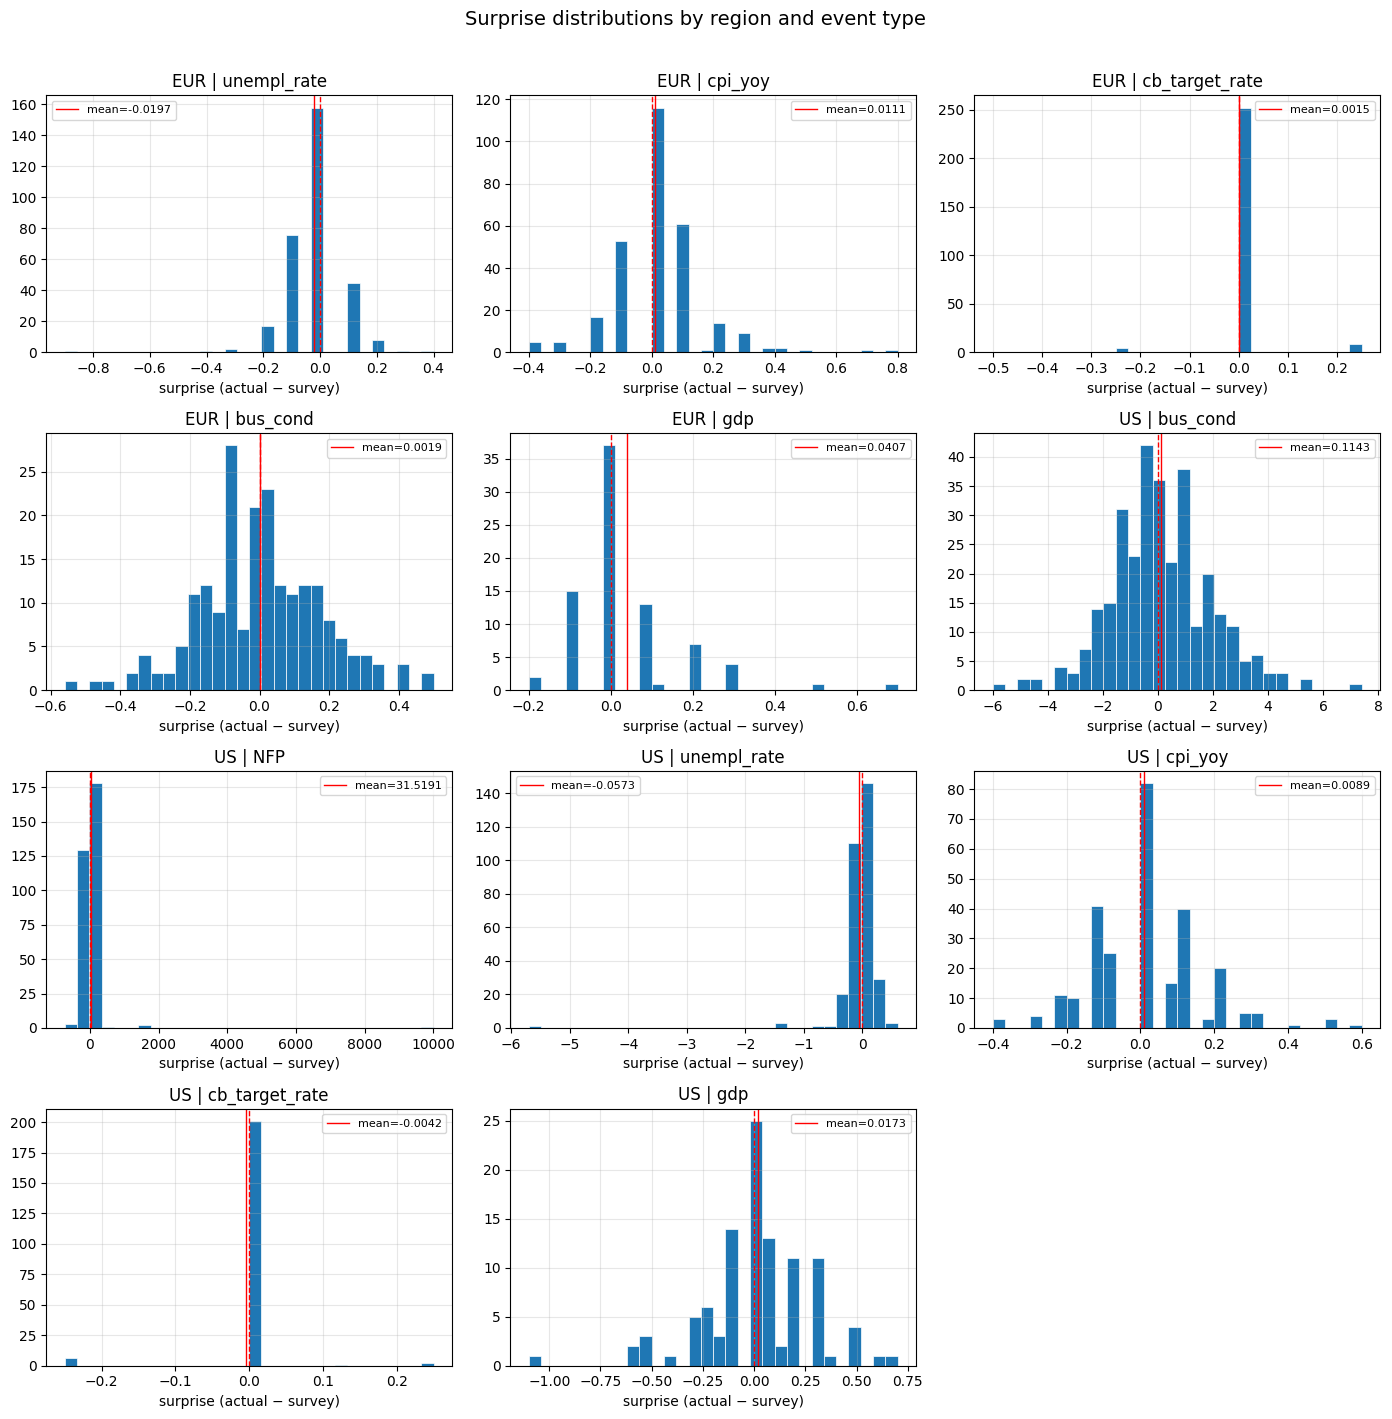

In [12]:
groups = surprise_stats.index.tolist()  # list of (region, event_name) tuples
n_groups = len(groups)
n_cols = 3
n_rows = (n_groups + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows))
axes = axes.ravel()

for ax, (region, name) in zip(axes, groups):
    vals = surprise_df.loc[
        (surprise_df["region"] == region) & (surprise_df["event_name"] == name), "surprise"
    ]
    ax.hist(vals, bins=30, edgecolor="white", linewidth=0.5)
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.axvline(vals.mean(), color="red", linestyle="-", linewidth=1, label=f"mean={vals.mean():.4f}")
    ax.set_title(f"{region} | {name}")
    ax.legend(fontsize=8)
    ax.set_xlabel("surprise (actual − survey)")
    ax.grid(alpha=0.3)

for ax in axes[n_groups:]:
    ax.axis("off")

plt.suptitle("Surprise distributions by region and event type", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Intraday volatility seasonality

c:\Users\AXZO\Documents\Code\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


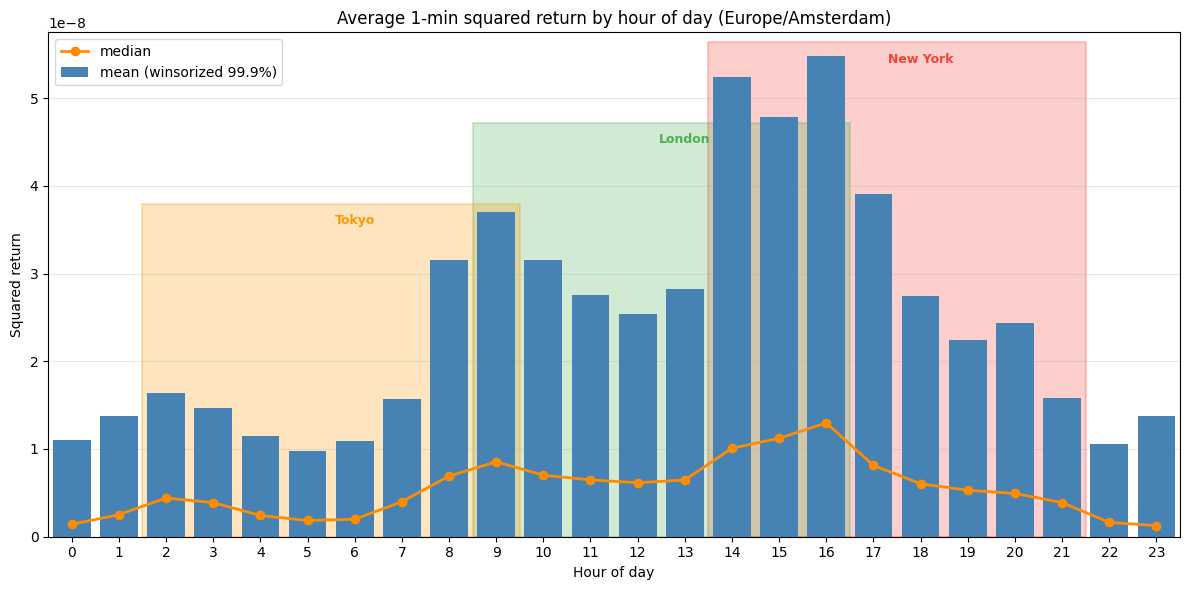

In [13]:
eurusd_vol = eurusd[["timestamp", "close"]].copy()
eurusd_vol["ret_1m"] = np.log(eurusd_vol["close"]).diff()
eurusd_vol["ret_sq"] = eurusd_vol["ret_1m"] ** 2
eurusd_vol["hour"] = eurusd_vol["timestamp"].dt.hour
eurusd_vol = eurusd_vol.dropna(subset=["ret_1m"])

# Winsorize at 99.9th percentile for robust hourly stats
ret_sq_999 = eurusd_vol["ret_sq"].quantile(0.999)
eurusd_vol_clean = eurusd_vol.copy()
eurusd_vol_clean["ret_sq_w"] = eurusd_vol_clean["ret_sq"].clip(upper=ret_sq_999)

hourly_rv = (
    eurusd_vol_clean.groupby("hour")
    .agg(
        mean_ret_sq=("ret_sq_w", "mean"),
        median_ret_sq=("ret_sq", "median"),
        n=("ret_sq", "count"),
    )
)

# Trading sessions in Europe/Amsterdam time — stacked by height
sessions = [
    {"label": "New York", "start": 14, "end": 22, "color": "#F44336", "ylo": 0.0, "yhi": 0.98},
    {"label": "London",   "start": 9,  "end": 17, "color": "#4CAF50", "ylo": 0.0, "yhi": 0.82},
    {"label": "Tokyo",    "start": 2,  "end": 10, "color": "#FF9800", "ylo": 0.0, "yhi": 0.66},
]

fig, ax = plt.subplots(figsize=(12, 6))

# Draw session boxes behind the data
trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)

for s in sessions:
    rect = plt.Rectangle(
        (s["start"] - 0.5, s["ylo"]), s["end"] - s["start"], s["yhi"] - s["ylo"],
        transform=trans, facecolor=s["color"], alpha=.25, edgecolor=s["color"],
        linewidth=1.5, zorder=0, clip_on=False,
    )
    ax.add_patch(rect)
    ax.text(
        (s["start"] + s["end"]) / 2, s["yhi"] - 0.02,
        s["label"], ha="center", va="top", fontsize=9, fontweight="bold",
        color=s["color"], transform=trans, zorder=5,
    )

ax.bar(hourly_rv.index, hourly_rv["mean_ret_sq"], color="steelblue", label="mean (winsorized 99.9%)", zorder=2)
ax.plot(hourly_rv.index, hourly_rv["median_ret_sq"], color="darkorange", marker="o", linewidth=2, label="median", zorder=3)
ax.set_title(f"Average 1-min squared return by hour of day ({ANALYSIS_TZ})")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Squared return")
ax.set_xticks(range(24))
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)
ax.set_xlim(-0.5, 23.5)
plt.tight_layout()
plt.show()

# Autocorrelation of squared returns

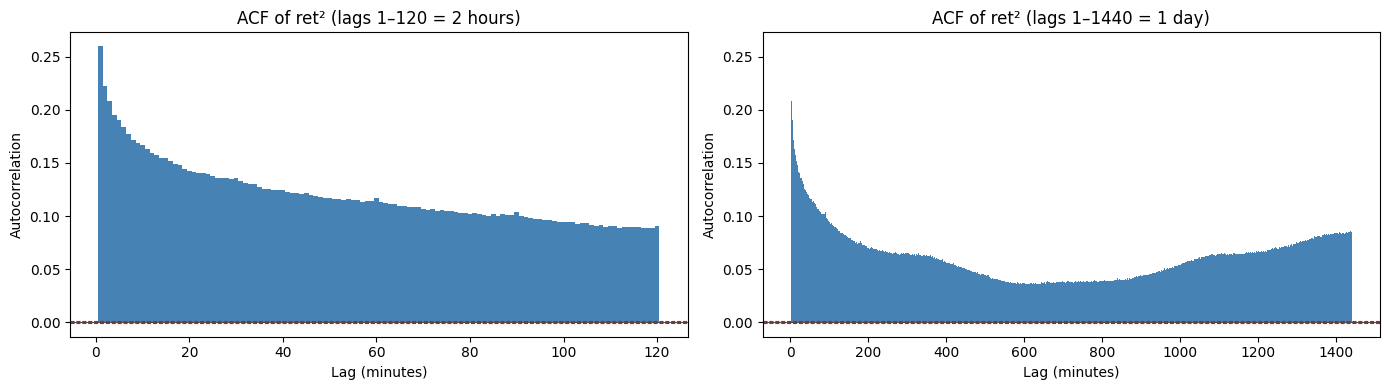

In [ ]:
max_lag = 1440
# Use winsorized squared returns to avoid bad-tick distortion
ret_sq_series = eurusd_vol_clean["ret_sq_w"].dropna().values

acf_vals = acf(ret_sq_series, nlags=max_lag, fft=True, alpha=None)
ci = 1.96 / np.sqrt(len(ret_sq_series))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.bar(range(1, 121), acf_vals[1:121], width=1, color="steelblue", edgecolor="none")
ax1.axhline(0, color="black", linewidth=0.5)
ax1.axhline(ci, color="red", linestyle="--", linewidth=0.8)
ax1.axhline(-ci, color="red", linestyle="--", linewidth=0.8)
ax1.set_title("ACF of ret² (lags 1–120 = 2 hours)")
ax1.set_xlabel("Lag (minutes)")
ax1.set_ylabel("Autocorrelation")

ax2.bar(range(1, max_lag + 1), acf_vals[1:], width=1, color="steelblue", edgecolor="none")
ax2.axhline(0, color="black", linewidth=0.5)
ax2.axhline(ci, color="red", linestyle="--", linewidth=0.8)
ax2.axhline(-ci, color="red", linestyle="--", linewidth=0.8)
ax2.set_title("ACF of ret² (lags 1–1440 = 1 day)")
ax2.set_xlabel("Lag (minutes)")
ax2.set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()